# Circle Object Detection 

### Mustafa Sefa Soysal


## 1) Imports

This section imports all necessary libraries from Python's scientific computing stack (NumPy, PyTorch) and defines custom data structures (`FeatureConfig`, `ModelConfig`, `LossConfig`) and utility functions (`_pairwise_distance_features`, `_radial_spread_features`, etc.) crucial for feature extraction, model definition, and loss calculation.

In [ ]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from dataclasses import dataclass
from typing import Dict, Tuple


@dataclass(frozen=True)
class FeatureConfig:
    radial_bins:    int = 64   # per candidate center
    angle_bins:     int = 36
    grid_proj_bins: int = 32
    hough_grid:     int = 5    # NxN candidate circle centers to try
    # Feature dim = radial_bins + angle_bins + 2*grid_proj_bins + 8 + 4 + 3 + 3 + hough_grid^2
    # = 64 + 36 + 64 + 8 + 4 + 3 + 3 + 25 = 207

    @property
    def feature_dim(self) -> int:
        return (self.radial_bins + self.angle_bins +
                2 * self.grid_proj_bins + 8 + 4 + self.hough_grid ** 2
                + 24 + 4)   # +24 pairwise dist, +4 radial spread




def _pairwise_distance_features(points: np.ndarray, n_bins: int = 20) -> np.ndarray:
    """
    Pairwise distance histogram + statistics.
    DETERMINISTIC — no random sampling involved.

    Why this helps:
      - Circle → specific chord-length distribution (peak at ~1.4r for full circle)
      - Line → bimodal distribution
      - Blob → concentrated near zero
      - Uniform → triangular distribution
    Each pattern produces a unique histogram shape.
    """
    n = len(points)
    if n < 3:
        return np.zeros(n_bins + 4, dtype=np.float32)

    # Subsample deterministically for efficiency (>200 pts → use first 200)
    if n > 200:
        step = n // 200
        pts = points[::step][:200]
    else:
        pts = points

    # Compute all pairwise distances
    dx = pts[:, 0, None] - pts[None, :, 0]   # (m, m)
    dy = pts[:, 1, None] - pts[None, :, 1]
    dists = np.sqrt(dx**2 + dy**2)

    # Upper triangle only (exclude diagonal)
    triu = dists[np.triu_indices(len(pts), k=1)]

    # Normalize to [0, 1] by max pairwise distance
    max_d = triu.max() + 1e-8
    triu_n = triu / max_d

    # Histogram
    hist, _ = np.histogram(triu_n, bins=n_bins, range=(0.0, 1.0))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)

    # 4 summary statistics
    m = float(triu_n.mean())
    s = float(triu_n.std()) + 1e-8
    skew = float(np.mean(((triu_n - m) / s) ** 3))
    kurt = float(np.mean(((triu_n - m) / s) ** 4))

    return np.concatenate([hist, np.array([m, s, skew, kurt], dtype=np.float32)])


def _radial_spread_features(points: np.ndarray, cx: float, cy: float,
                            scale: float) -> np.ndarray:
    """
    Radial spread stats from best Hough center.
    Helps thickness: thin → tight spread, medium → wider spread.
    DETERMINISTIC.
    """
    dx = points[:, 0] - cx
    dy = points[:, 1] - cy
    dists = np.sqrt(dx**2 + dy**2) / (scale + 1e-8)

    if len(dists) < 3:
        return np.zeros(4, dtype=np.float32)

    med = float(np.median(dists))

    # IQR of radial distances
    iqr = float(np.quantile(dists, 0.75) - np.quantile(dists, 0.25))

    # MAD (median absolute deviation) — robust ring width measure
    mad = float(np.median(np.abs(dists - med)))

    # Concentration: fraction of points within 10% of median radius
    concentration = float(np.mean(np.abs(dists - med) < 0.1 * (med + 1e-8)))

    # Ring tightness: std / mean ratio (low for thin, high for medium)
    cv = float(np.std(dists) / (np.mean(dists) + 1e-8))

    return np.array([iqr, mad, concentration, cv], dtype=np.float32)


def _radial_sharpness(points: np.ndarray, cx: float, cy: float,
                      R: int, scale: float) -> Tuple[float, np.ndarray]:
    """Radial histogram + sharpness from a given center point."""
    dx = points[:, 0] - cx
    dy = points[:, 1] - cy
    dists = np.sqrt(dx**2 + dy**2) / (scale + 1e-8)
    hist, _ = np.histogram(dists, bins=R, range=(0.0, 1.5))
    hist = hist.astype(np.float32) / (hist.sum() + 1e-8)
    pi  = int(np.argmax(hist))
    nm  = float(hist[np.arange(R) != pi].mean())
    sharpness = float(hist[pi]) / (nm + 1e-8)
    return sharpness, hist


def _angular_stats(angles: np.ndarray, A: int) -> np.ndarray:
    """Angular coverage + entropy + max gap (normalized)."""
    if angles.size == 0:
        return np.zeros(3, dtype=np.float32)
    hist, _ = np.histogram(angles, bins=A, range=(-np.pi, np.pi))
    coverage = float((hist > 0).mean())
    probs = hist.astype(np.float32) / (hist.sum() + 1e-8)
    entropy = -float(np.sum(probs * np.log(probs + 1e-8))) / np.log(A)
    ang_sorted = np.sort(angles)
    if ang_sorted.size < 2:
        max_gap = 1.0
    else:
        gaps = np.diff(ang_sorted)
        wrap_gap = (ang_sorted[0] + 2 * np.pi) - ang_sorted[-1]
        max_gap = float(np.max(np.concatenate([gaps, [wrap_gap]])) / (2 * np.pi))
    return np.array([coverage, entropy, max_gap], dtype=np.float32)


def _circle_from_3pts(p1: np.ndarray, p2: np.ndarray, p3: np.ndarray) -> Tuple[float, float, float] | None:
    ax, ay = float(p1[0]), float(p1[1])
    bx, by = float(p2[0]), float(p2[1])
    cx, cy = float(p3[0]), float(p3[1])
    d = 2.0 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    if abs(d) < 1e-8:
        return None
    ax2ay2 = ax * ax + ay * ay
    bx2by2 = bx * bx + by * by
    cx2cy2 = cx * cx + cy * cy
    ux = (ax2ay2 * (by - cy) + bx2by2 * (cy - ay) + cx2cy2 * (ay - by)) / d
    uy = (ax2ay2 * (cx - bx) + bx2by2 * (ax - cx) + cx2cy2 * (bx - ax)) / d
    r = np.sqrt((ux - ax) ** 2 + (uy - ay) ** 2)
    return float(ux), float(uy), float(r)


def _ransac_circle_stats(points: np.ndarray, scale: float, n_iters: int = 40,
                         inlier_thresh: float = 0.03) -> np.ndarray:
    """Lightweight RANSAC: best inlier ratio + mean residual + radius (normalized)."""
    n = points.shape[0]
    if n < 3:
        return np.zeros(3, dtype=np.float32)
    rng = np.random.default_rng(0)
    best_ratio, best_res, best_r = 0.0, 1e9, 0.0
    thr = inlier_thresh * scale
    for _ in range(n_iters):
        idx = rng.choice(n, size=3, replace=False)
        circle = _circle_from_3pts(points[idx[0]], points[idx[1]], points[idx[2]])
        if circle is None:
            continue
        cx, cy, r = circle
        dists = np.sqrt((points[:, 0] - cx) ** 2 + (points[:, 1] - cy) ** 2)
        residuals = np.abs(dists - r)
        inliers = residuals <= thr
        ratio = float(inliers.mean())
        if inliers.any():
            res = float(residuals[inliers].mean())
        else:
            res = float(residuals.mean())
        if (ratio > best_ratio) or (ratio == best_ratio and res < best_res):
            best_ratio, best_res, best_r = ratio, res, r
    return np.array([best_ratio, best_res / (scale + 1e-8), best_r / (scale + 1e-8)], dtype=np.float32)


def extract_features(points: np.ndarray, cfg: FeatureConfig) -> np.ndarray:
    """
    Extract fixed-size geometric features from a variable-length point cloud.

    Key insight from diagnostic plots:
      Circle present → sharp peak in radial distance histogram
      No circle      → flat/broad radial histogram

    Improvement over v6: instead of using the centroid as the only reference
    center (which is biased when the circle is not centered on the cloud),
    we try a grid of candidate centers (Hough-like) and take the best one.
    This is still pure feature engineering — no CNN, no Transformer.

    Feature layout (207 dims total):
      [0  :64 ] Radial histogram from BEST candidate center
      [64 :100] Angle histogram from best center
      [100:132] X marginal projection
      [132:164] Y marginal projection
      [164:172] Global statistics (mean/std/skew/kurt of dx, dy)
      [172:176] Radial peak stats (peak_val, peak_pos, sharpness, ring_frac)
      [176:179] Angular stats (coverage, entropy, max_gap)
      [179:182] RANSAC circle fit (inlier_ratio, mean_residual, radius)
      [182:207] Hough sharpness map (5×5 grid flattened)
    """
    R = cfg.radial_bins
    A = cfg.angle_bins
    G = cfg.grid_proj_bins
    N = cfg.hough_grid

    # Robust scale from median center
    med_cx = np.median(points[:, 0])
    med_cy = np.median(points[:, 1])
    dx0 = points[:, 0] - med_cx
    dy0 = points[:, 1] - med_cy
    dists0 = np.sqrt(dx0**2 + dy0**2)
    scale  = np.quantile(dists0, 0.90) + 1e-8

    # ── Hough-like: try N×N candidate centers, record sharpness map ──────────
    x_lo = np.quantile(points[:, 0], 0.15)
    x_hi = np.quantile(points[:, 0], 0.85)
    y_lo = np.quantile(points[:, 1], 0.15)
    y_hi = np.quantile(points[:, 1], 0.85)
    xs   = np.linspace(x_lo, x_hi, N)
    ys   = np.linspace(y_lo, y_hi, N)

    hough_map  = np.zeros((N, N), dtype=np.float32)
    best_sharp = -1.0
    best_hist  = None
    best_cx    = med_cx
    best_cy    = med_cy

    for i, tx in enumerate(xs):
        for j, ty in enumerate(ys):
            sh, hist = _radial_sharpness(points, tx, ty, R, scale)
            hough_map[i, j] = sh
            if sh > best_sharp:
                best_sharp = sh
                best_hist  = hist
                best_cx    = tx
                best_cy    = ty

    # Normalize hough map to [0, 1]
    hough_flat = hough_map.flatten() / (hough_map.max() + 1e-8)

    # ── Angle histogram from best center ─────────────────────────────────────
    dx_b   = points[:, 0] - best_cx
    dy_b   = points[:, 1] - best_cy
    angles = np.arctan2(dy_b, dx_b)
    ang_hist, _ = np.histogram(angles, bins=A, range=(-np.pi, np.pi))
    ang_hist     = ang_hist.astype(np.float32) / (ang_hist.sum() + 1e-8)

    # ── X/Y marginal projections ──────────────────────────────────────────────
    x_proj, _ = np.histogram(points[:, 0], bins=G,
                              range=(np.quantile(points[:, 0], 0.02),
                                     np.quantile(points[:, 0], 0.98)))
    y_proj, _ = np.histogram(points[:, 1], bins=G,
                              range=(np.quantile(points[:, 1], 0.02),
                                     np.quantile(points[:, 1], 0.98)))
    x_proj = x_proj.astype(np.float32) / (x_proj.sum() + 1e-8)
    y_proj = y_proj.astype(np.float32) / (y_proj.sum() + 1e-8)

    # ── Global statistics ─────────────────────────────────────────────────────
    def safe_stat(v):
        m = v.mean(); s = v.std() + 1e-8
        sk = float(np.mean(((v - m) / s) ** 3))
        ku = float(np.mean(((v - m) / s) ** 4))
        return [float(m), float(s), sk, ku]
    gs = np.array(safe_stat(dx0 / scale) + safe_stat(dy0 / scale), dtype=np.float32)

    # ── Radial peak statistics from best histogram ────────────────────────────
    pi  = int(np.argmax(best_hist))
    pv  = float(best_hist[pi])
    pp  = float(pi / R)
    nm  = float(best_hist[np.arange(R) != pi].mean())
    sh  = pv / (nm + 1e-8)
    lo  = max(0, pi - 2); hi = min(R, pi + 3)
    rf  = float(best_hist[lo:hi].sum())
    peak_stats = np.array([pv, pp, sh, rf], dtype=np.float32)

    # ── Pairwise distance features (deterministic, no RANSAC) ────────────────
    pair_feats = _pairwise_distance_features(points, n_bins=20)

    # ── Radial spread from best center (helps thickness) ─────────────────────
    spread_feats = _radial_spread_features(points, best_cx, best_cy, scale)

    return np.concatenate([best_hist, ang_hist, x_proj, y_proj,
                           gs, peak_stats, hough_flat,
                           pair_feats, spread_feats]).astype(np.float32)


def normalize_circle_params(cx, cy, r, points):
    x_lo = np.quantile(points[:, 0], 0.02)
    x_hi = np.quantile(points[:, 0], 0.98)
    y_lo = np.quantile(points[:, 1], 0.02)
    y_hi = np.quantile(points[:, 1], 0.98)
    xc = (x_lo + x_hi) / 2;  yc = (y_lo + y_hi) / 2
    s  = max(x_hi - x_lo, y_hi - y_lo) * 1.1 + 1e-8
    x_left = xc - s/2;  y_top = yc + s/2
    return np.array([(cx - x_left)/s, (y_top - cy)/s, r/s], dtype=np.float32)


class CircleDataset(Dataset):
    def __init__(self, data_path, indices=None, feat_cfg=None, augment=False):
        self.feat_cfg = feat_cfg or FeatureConfig()
        self.augment  = augment
        with np.load(data_path, allow_pickle=True) as data:
            self.points  = data["points"]
            self.targets = data["targets7"]
        self.indices = np.arange(len(self.points)) if indices is None else indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        points   = self.points[real_idx].copy().astype(np.float32)
        targets  = self.targets[real_idx].astype(np.float32).copy()
        has_circle = targets[0] > 0.5

        if self.augment:
            # Random rotation — always safe (circles are rotation-invariant)
            theta = np.random.uniform(0, 2*np.pi)
            cos_t, sin_t = np.cos(theta), np.sin(theta)
            x_rot =  cos_t * points[:, 0] - sin_t * points[:, 1]
            y_rot =  sin_t * points[:, 0] + cos_t * points[:, 1]
            points[:, 0], points[:, 1] = x_rot, y_rot
            if has_circle:
                cx_r = cos_t * targets[4] - sin_t * targets[5]
                cy_r = sin_t * targets[4] + cos_t * targets[5]
                targets[4], targets[5] = cx_r, cy_r

            # Random flip — must mirror circle center too
            if has_circle:
                if np.random.rand() < 0.5:
                    mx = points[:, 0].mean()
                    points[:, 0] = 2*mx - points[:, 0]
                    targets[4]   = 2*mx - targets[4]
                if np.random.rand() < 0.5:
                    my = points[:, 1].mean()
                    points[:, 1] = 2*my - points[:, 1]
                    targets[5]   = 2*my - targets[5]
            else:
                if np.random.rand() < 0.5: points[:, 0] *= -1
                if np.random.rand() < 0.5: points[:, 1] *= -1

        feat = extract_features(points, self.feat_cfg)
        if has_circle:
            targets[4:7] = normalize_circle_params(targets[4], targets[5], targets[6], points)
        return torch.from_numpy(feat).float(), torch.from_numpy(targets).float()


def split_indices(n, val_ratio, seed):
    rng = np.random.default_rng(seed)
    idx = np.arange(n); rng.shuffle(idx)
    split = int(n * (1.0 - val_ratio))
    return idx[:split], idx[split:]


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE NORMALIZER
# Computes mean/std from training set, applies z-score to all splits.
# Critical because our features have very different scales:
#   radial histogram bins: ~0.01–0.09  (probability values)
#   sharpness score:       ~4–10       (ratio, much larger)
#   global statistics:     varies
# Without normalization, large-scale features dominate the first Linear layer.
# ─────────────────────────────────────────────────────────────────────────────

class FeatureNormalizer:
    """Fit on training features, transform all splits."""
    def __init__(self):
        self.mean: np.ndarray | None = None
        self.std:  np.ndarray | None = None

    def fit(self, dataset: "CircleDataset") -> "FeatureNormalizer":
        feats = np.stack([dataset[i][0].numpy() for i in range(len(dataset))])
        self.mean = feats.mean(axis=0).astype(np.float32)
        self.std  = (feats.std(axis=0) + 1e-8).astype(np.float32)
        print(f"Normalizer fit on {len(dataset)} samples | "
              f"feat dim={feats.shape[1]} | "
              f"mean range [{self.mean.min():.3f}, {self.mean.max():.3f}]")
        return self

    def transform(self, x: torch.Tensor) -> torch.Tensor:
        mean = torch.from_numpy(self.mean).to(x.device)
        std  = torch.from_numpy(self.std).to(x.device)
        return (x - mean) / std

    def save(self, path: str):
        np.savez(path, mean=self.mean, std=self.std)

    @classmethod
    def load(cls, path: str) -> "FeatureNormalizer":
        data = np.load(path)
        n = cls()
        n.mean = data["mean"]
        n.std  = data["std"]
        return n


In [ ]:
@dataclass(frozen=True)
class ModelConfig:
    feature_dim:      int             = 201
    trunk_sizes:      Tuple[int, ...] = (512, 384, 256)    # v7 exact
    exist_head_sizes: Tuple[int, ...] = (128, 64)          # v7 exact
    thick_head_size:  int             = 128                 # v7 exact
    params_head_size: int             = 64                  # v7 exact
    dropout:          float           = 0.25                # v7 exact


class CircleNet(nn.Module):
    """
    Pure MLP — v7 architecture (proven 0.83 exist_acc).
    Course-compliant: no CNN, no Transformer.
    """
    def __init__(self, config: ModelConfig | None = None) -> None:
        super().__init__()
        cfg = config or ModelConfig()

        # Shared trunk (v7 exact)
        trunk, prev = [], cfg.feature_dim
        for i, h in enumerate(cfg.trunk_sizes):
            drop = cfg.dropout if i < len(cfg.trunk_sizes)-1 else cfg.dropout*0.5
            trunk += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                      nn.ReLU(inplace=True), nn.Dropout(drop)]
            prev = h
        self.trunk = nn.Sequential(*trunk)
        tout = cfg.trunk_sizes[-1]

        # Existence head (v7 exact)
        elayers, prev_e = [], tout
        for h in cfg.exist_head_sizes:
            elayers += [nn.Linear(prev_e, h), nn.BatchNorm1d(h),
                        nn.ReLU(inplace=True), nn.Dropout(0.1)]
            prev_e = h
        elayers.append(nn.Linear(prev_e, 1))
        self.existence_head = nn.Sequential(*elayers)

        # Thickness head (v7 exact)
        self.thickness_head = nn.Sequential(
            nn.Linear(tout, cfg.thick_head_size), nn.ReLU(inplace=True),
            nn.Dropout(0.1), nn.Linear(cfg.thick_head_size, 3))

        # Params head (v7 exact)
        self.params_head = nn.Sequential(
            nn.Linear(tout, cfg.params_head_size), nn.ReLU(inplace=True),
            nn.Linear(cfg.params_head_size, 3))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        shared = self.trunk(x)
        return {
            "existence_logits": self.existence_head(shared),
            "thickness_logits": self.thickness_head(shared),
            "params":           self.params_head(shared),
        }


In [ ]:
@dataclass(frozen=True)
class LossConfig:
    existence_weight:    float = 1.5    # mild boost (v7 was 1.0)
    thickness_weight:    float = 1.0    # v7 exact
    params_weight:       float = 0.8    # slightly reduce (v7 was 1.0)
    thickness_smoothing: float = 0.1    # v7 exact


class MultiTaskLoss(nn.Module):
    def __init__(self, config: LossConfig | None = None, pos_weight: float = 1.0) -> None:
        super().__init__()
        self.config = config or LossConfig()
        self.exist_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
        self.thick_loss = nn.CrossEntropyLoss(
            reduction="none", label_smoothing=self.config.thickness_smoothing)
        self.param_loss = nn.SmoothL1Loss(reduction="none")

    def forward(self, outputs, targets):
        exist_logits  = outputs["existence_logits"].squeeze(1)
        thick_logits  = outputs["thickness_logits"]
        params_pred   = outputs["params"]

        exist_target  = targets[:, 0].float()
        thick_target  = targets[:, 1:4].argmax(dim=1)
        params_target = targets[:, 4:7]

        loss_exist = self.exist_loss(exist_logits, exist_target)

        mask  = exist_target
        n_pos = mask.sum().clamp(min=1.0)
        loss_thick  = (self.thick_loss(thick_logits, thick_target) * mask).sum() / n_pos
        loss_params = (self.param_loss(params_pred, params_target).mean(dim=1) * mask).sum() / n_pos

        total = (self.config.existence_weight  * loss_exist
               + self.config.thickness_weight  * loss_thick
               + self.config.params_weight     * loss_params)

        return {"total": total, "existence": loss_exist.detach(),
                "thickness": loss_thick.detach(), "params": loss_params.detach()}


def find_best_threshold(model, loader, device, normalizer=None):
    model.eval()
    all_logits, all_targets = [], []
    with torch.no_grad():
        for feats, tgts in loader:
            f = feats.to(device)
            if normalizer is not None: f = normalizer.transform(f)
            out = model(f)
            all_logits.append(out["existence_logits"].squeeze(1).cpu())
            all_targets.append(tgts[:, 0])
    probs   = torch.sigmoid(torch.cat(all_logits)).numpy()
    targets = torch.cat(all_targets).numpy()
    best_t, best_acc = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, 81):
        acc = ((probs >= t) == targets.astype(bool)).mean()
        if acc > best_acc:
            best_acc, best_t = acc, float(t)
    print(f"Best threshold: {best_t:.3f}  ->  val existence acc: {best_acc:.4f}")
    return best_t


def compute_metrics(outputs, targets, exist_threshold=0.5):
    exist_logits = outputs["existence_logits"].squeeze(1)
    exist_target = targets[:, 0].float()
    thick_target = targets[:, 1:4].argmax(dim=1)

    exist_pred = (torch.sigmoid(exist_logits) >= exist_threshold).float()
    exist_acc  = (exist_pred == exist_target).float().mean()

    mask  = exist_target
    n_pos = mask.sum().clamp(min=1.0)
    thick_acc = ((outputs["thickness_logits"].argmax(1) == thick_target).float() * mask).sum() / n_pos
    param_mae = ((outputs["params"] - targets[:, 4:7]).abs().mean(dim=1) * mask).sum() / n_pos

    return {"existence_acc": exist_acc.detach(),
            "thickness_acc": thick_acc.detach(),
            "params_mae":    param_mae.detach()}


In [ ]:
def run_epoch(model, loss_fn, loader, optimizer, device,
              normalizer=None, clip_grad=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    totals = dict(total_loss=0., existence_loss=0., thickness_loss=0.,
                  params_loss=0., existence_acc=0., thickness_acc=0.)
    n = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for feats, targets in loader:
            feats, targets = feats.to(device), targets.to(device)
            if normalizer is not None:
                feats = normalizer.transform(feats)
            outputs = model(feats)
            losses  = loss_fn(outputs, targets)
            metrics = compute_metrics(outputs, targets)
            if is_train:
                optimizer.zero_grad()
                losses["total"].backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()
            bs = feats.size(0);  n += bs
            totals["total_loss"]     += float(losses["total"].detach())    * bs
            totals["existence_loss"] += float(losses["existence"])         * bs
            totals["thickness_loss"] += float(losses["thickness"])         * bs
            totals["params_loss"]    += float(losses["params"])            * bs
            totals["existence_acc"]  += float(metrics["existence_acc"])    * bs
            totals["thickness_acc"]  += float(metrics["thickness_acc"])    * bs
    return {k: v/n for k, v in totals.items()}


## 2) Colab Setup

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print(f"Drive mount skipped: {exc}")

TRAIN_PATH = "/content/drive/MyDrive/Neural_Networks_Homework1_2/dataset/train/dataset_all.npz"
TEST_PATH  = "/content/drive/MyDrive/Neural_Networks_Homework1_2/dataset/test/dataset_all.npz"

Mounted at /content/drive


This section handles Google Colab specific setup, including mounting Google Drive to access the dataset files. It then defines the paths to the training and testing datasets.

## 2.5) Synthetic Data Generation

Aşağıdaki hücre, hocanın orijinal `dataset_all.npz` formatıyla **birebir uyumlu** synthetic veri üretir ve diske kaydeder.

- **Pozitif örnekler**: ince (`thin`) ya da orta (`medium`) kalınlıkta dairesel nokta bulutu + Gaussian gürültü  
- **Negatif örnekler**: 9 farklı bozucu örüntü (line, cross_lines, spiral, ellipse, blob, two_blobs, uniform, rectangle, mixed)  
- Üretilen veri `TRAIN_PATH` / `TEST_PATH` değişkenlerine otomatik atanır; sonraki hücreler değişmeden çalışır.

In [ ]:
# Synthetic data generation SKIPPED — using instructor's real dataset.
# TRAIN_PATH and TEST_PATH are already set in Cell 7 (Colab Setup).
print(f"TRAIN_PATH → {TRAIN_PATH}")
print(f"TEST_PATH  → {TEST_PATH}")


TRAIN_PATH → /content/drive/MyDrive/Neural_Networks_Homework1_2/dataset/train/dataset_all.npz
TEST_PATH  → /content/drive/MyDrive/Neural_Networks_Homework1_2/dataset/test/dataset_all.npz


## 3) Dataset Inspection

Here, we load the raw dataset to understand its structure and properties. This includes checking the number of samples, the shape of target labels, and performing class balance analysis for circle existence and thickness categories. This information is used to calculate `pos_weight` for the existence loss and `thickness_weights` for the thickness loss, addressing potential class imbalance.

In [ ]:
with np.load(TRAIN_PATH, allow_pickle=True) as data:
    print("Keys:", data.files)
    n_samples = len(data['points'])
    targets_all = data['targets7']
    print(f"Samples: {n_samples}  |  targets shape: {targets_all.shape}")

    # Check class balance
    existence = targets_all[:, 0]
    pos = existence.sum()
    neg = n_samples - pos
    print(f"Circle present: {pos} ({100*pos/n_samples:.1f}%)  |  absent: {neg} ({100*neg/n_samples:.1f}%)")
    pos_weight = neg / max(pos, 1)
    print(f"=> Using pos_weight = {pos_weight:.3f} for existence BCE")

    # Thickness class weights (inverse frequency)
    thickness_labels = targets_all[:, 1:4].argmax(axis=1)
    thick_counts = np.bincount(thickness_labels, minlength=3).astype(np.float32)
    thick_weights = thick_counts.sum() / np.maximum(thick_counts, 1)
    thick_weights = thick_weights / thick_weights.mean()
    thickness_weights = torch.tensor(thick_weights, dtype=torch.float32)
    print("Thickness counts:", thick_counts)
    print("Thickness weights:", thick_weights)

Keys: ['points', 'targets7', 'metadata']
Samples: 2000  |  targets shape: (2000, 7)
Circle present: 1122.0 (56.1%)  |  absent: 878.0 (43.9%)
=> Using pos_weight = 0.783 for existence BCE
Thickness counts: [656. 683. 661.]
Thickness weights: [1.0159489 0.9757869 1.008264 ]


## 4) Training Phase

### 4.1  Config

The training phase is the core of the homework, where the neural network model is built and optimized.

In [ ]:
feat_cfg = FeatureConfig(
    radial_bins    = 64,
    angle_bins     = 36,
    grid_proj_bins = 32,
    hough_grid     = 5,    # 5×5 = 25 candidate centers (Hough-like)
)
print(f"Feature vector dimension: {feat_cfg.feature_dim}")


Feature vector dimension: 229


We define the `FeatureConfig` to specify parameters for feature extraction, such as the number of bins for radial and angular histograms, grid projection, and Hough grid size. The total feature vector dimension is then calculated based on these parameters.

### 4.2  Split + DataLoaders

The dataset is split into training and validation sets. `CircleDataset` and `DataLoader` are instantiated for both sets, with data augmentation applied to the training set. A `FeatureNormalizer` is fitted on the training data to standardize features, which is crucial for stable neural network training.

In [ ]:
train_idx, val_idx = split_indices(n_samples, val_ratio=0.15, seed=42)

train_ds = CircleDataset(TRAIN_PATH, indices=train_idx, feat_cfg=feat_cfg, augment=True)
val_ds   = CircleDataset(TRAIN_PATH, indices=val_idx,   feat_cfg=feat_cfg, augment=False)

# Fit normalizer on training set (no augmentation version to get clean stats)
train_ds_noaug = CircleDataset(TRAIN_PATH, indices=train_idx, feat_cfg=feat_cfg, augment=False)
normalizer = FeatureNormalizer().fit(train_ds_noaug)
del train_ds_noaug

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

feat0, tgt0 = train_ds[0]
print(f"Feature shape: {feat0.shape}  |  Target shape: {tgt0.shape}")
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")


Normalizer fit on 1700 samples | feat dim=229 | mean range [-0.002, 9.047]
Feature shape: torch.Size([229])  |  Target shape: torch.Size([7])
Train: 1700  |  Val: 300


### 4.3  Model, Loss, Optimiser

This step defines the `CircleNet` model architecture (a multi-layer perceptron), the `MultiTaskLoss` function (combining BCEWithLogitsLoss for existence, CrossEntropyLoss for thickness, and SmoothL1Loss for parameters), and the AdamW optimizer with a CosineAnnealingLR scheduler for learning rate adjustment.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_config = ModelConfig(
    feature_dim      = feat_cfg.feature_dim,   # 201
    trunk_sizes      = (512, 384, 256),        # v7 exact
    exist_head_sizes = (128, 64),              # v7 exact
    thick_head_size  = 128,                    # v7 exact
    params_head_size = 64,                     # v7 exact
    dropout          = 0.25,                   # v7 exact
)
model = CircleNet(model_config).to(device)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

loss_fn = MultiTaskLoss(
    config     = LossConfig(
        existence_weight    = 1.5,
        thickness_weight    = 1.0,
        params_weight       = 0.8,
        thickness_smoothing = 0.1,
    ),
    pos_weight = float(pos_weight),
).to(device)

# v7 exact training config
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
N_EPOCHS  = 300
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)


Device: cuda
Trainable parameters: 507,143


### 4.4  Training Loop

The model is trained over multiple epochs, evaluating performance on both training and validation sets. Metrics like total loss, existence accuracy, and thickness accuracy are tracked. Early stopping is implemented based on validation loss to prevent overfitting, and the best model state is saved.

In [ ]:
history = {
    "train_total":      [], "val_total":      [],
    "train_exist_loss": [], "val_exist_loss": [],
    "train_thick_loss": [], "val_thick_loss": [],
    "train_params_loss":[], "val_params_loss":[],
    "train_exist_acc":  [], "val_exist_acc":  [],
    "train_thick_acc":  [], "val_thick_acc":  [],
}

best_val         = float('inf')
patience         = 35
epochs_no_improv = 0
SAVE_PATH        = 'best_model.pt'

for epoch in range(1, N_EPOCHS + 1):
    tr = run_epoch(model, loss_fn, train_loader, optimizer, device, normalizer)
    vl = run_epoch(model, loss_fn, val_loader,   None,      device, normalizer)
    scheduler.step()

    history['train_total'].append(tr['total_loss'])
    history['val_total'].append(vl['total_loss'])
    history['train_exist_loss'].append(tr['existence_loss'])
    history['val_exist_loss'].append(vl['existence_loss'])
    history['train_thick_loss'].append(tr['thickness_loss'])
    history['val_thick_loss'].append(vl['thickness_loss'])
    history['train_params_loss'].append(tr['params_loss'])
    history['val_params_loss'].append(vl['params_loss'])
    history['train_exist_acc'].append(tr['existence_acc'])
    history['val_exist_acc'].append(vl['existence_acc'])
    history['train_thick_acc'].append(tr['thickness_acc'])
    history['val_thick_acc'].append(vl['thickness_acc'])

    lr_now = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch:03d} | "
        f"loss {tr['total_loss']:.4f}/{vl['total_loss']:.4f} | "
        f"exist_acc {tr['existence_acc']:.4f}/{vl['existence_acc']:.4f} | "
        f"thick_acc {tr['thickness_acc']:.4f}/{vl['thickness_acc']:.4f} | "
        f"lr {lr_now:.6f}"
    )

    if vl['total_loss'] < best_val:
        best_val         = vl['total_loss']
        epochs_no_improv = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        epochs_no_improv += 1
        if epochs_no_improv >= patience:
            print('Early stopping triggered.')
            break

print(f"Best val loss: {best_val:.4f}")


Epoch 001 | loss 2.6001/2.0886 | exist_acc 0.5088/0.6033 | thick_acc 0.3362/0.4211 | lr 0.000300
Epoch 002 | loss 2.3674/1.9773 | exist_acc 0.5824/0.6700 | thick_acc 0.3793/0.4042 | lr 0.000300
Epoch 003 | loss 2.2003/1.9284 | exist_acc 0.6176/0.7100 | thick_acc 0.3899/0.4106 | lr 0.000300
Epoch 004 | loss 2.0906/1.8876 | exist_acc 0.6429/0.7100 | thick_acc 0.3929/0.4106 | lr 0.000300
Epoch 005 | loss 2.0737/1.8626 | exist_acc 0.6529/0.7367 | thick_acc 0.4029/0.4336 | lr 0.000300
Epoch 006 | loss 2.0298/1.8497 | exist_acc 0.6782/0.7400 | thick_acc 0.3882/0.4211 | lr 0.000300
Epoch 007 | loss 1.9588/1.8254 | exist_acc 0.6812/0.7500 | thick_acc 0.4167/0.4403 | lr 0.000300
Epoch 008 | loss 1.9721/1.8126 | exist_acc 0.7029/0.7567 | thick_acc 0.3951/0.4355 | lr 0.000299
Epoch 009 | loss 1.9269/1.7958 | exist_acc 0.7024/0.7700 | thick_acc 0.4444/0.4229 | lr 0.000299
Epoch 010 | loss 1.9094/1.7736 | exist_acc 0.7112/0.7700 | thick_acc 0.4129/0.4487 | lr 0.000299
Epoch 011 | loss 1.8538/1.7576

### 4.5  Plot Metrics

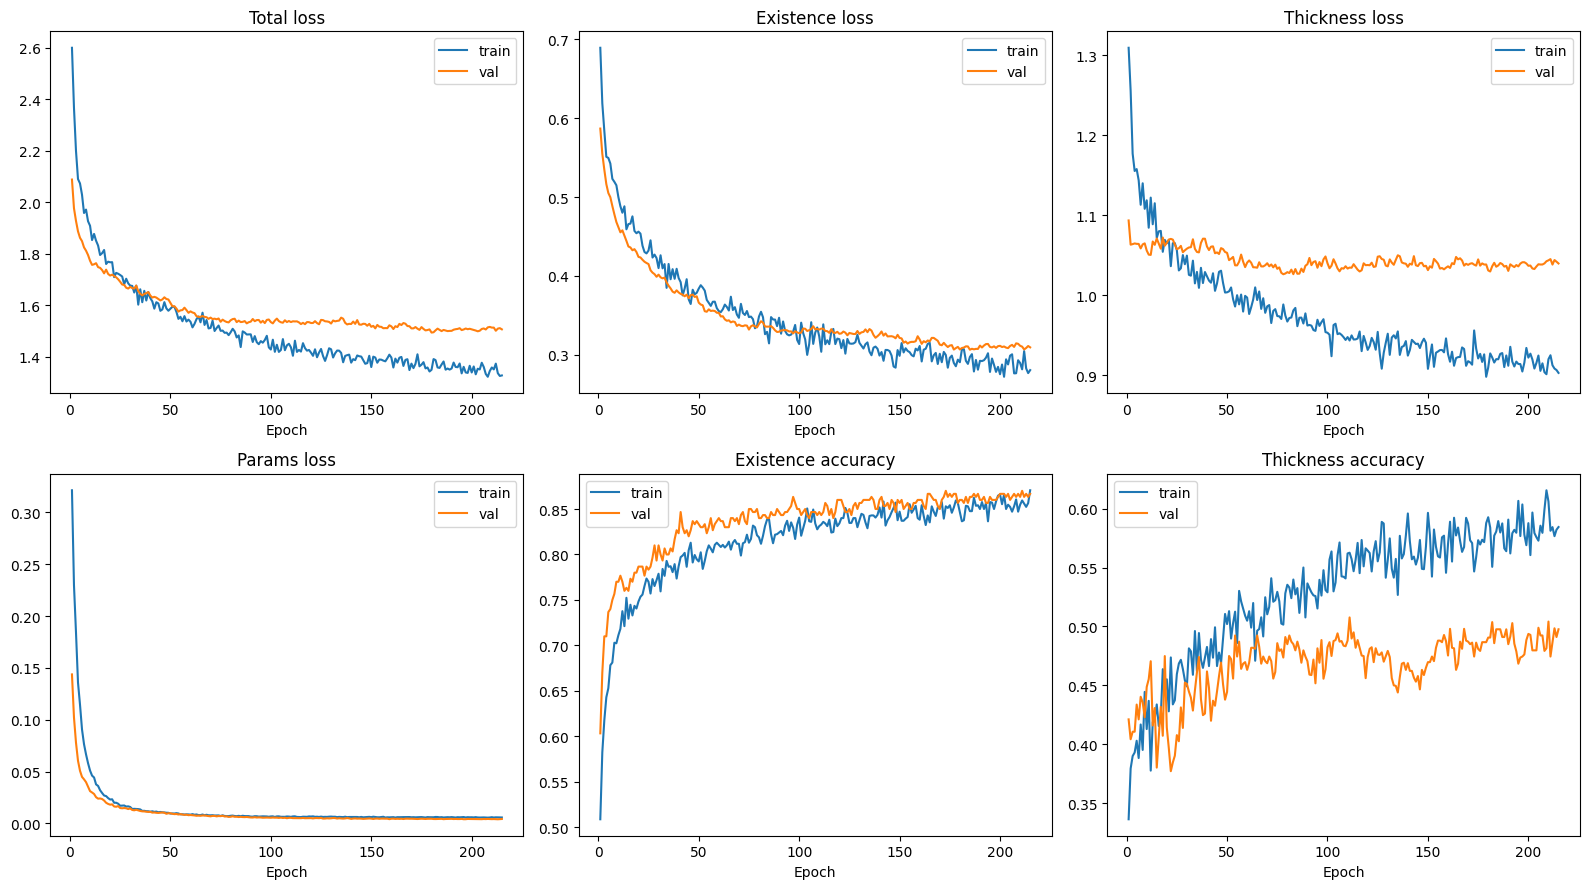

In [ ]:
import matplotlib.pyplot as plt

E = list(range(1, len(history['train_total']) + 1))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
pairs = [
    ('train_total',      'val_total',      'Total loss'),
    ('train_exist_loss', 'val_exist_loss',  'Existence loss'),
    ('train_thick_loss', 'val_thick_loss',  'Thickness loss'),
    ('train_params_loss','val_params_loss', 'Params loss'),
    ('train_exist_acc',  'val_exist_acc',   'Existence accuracy'),
    ('train_thick_acc',  'val_thick_acc',   'Thickness accuracy'),
]
for ax, (tr_key, vl_key, title) in zip(axes.flat, pairs):
    ax.plot(E, history[tr_key], label='train')
    ax.plot(E, history[vl_key], label='val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

After training, this section visualizes the training and validation curves for various loss components and accuracies, providing insights into the model's learning progress and potential overfitting.

## 5) Testing Phase

The final phase evaluates the trained model on a completely unseen test dataset.

In [ ]:
test_ds     = CircleDataset(TEST_PATH, feat_cfg=feat_cfg, augment=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
best_thresh = find_best_threshold(model, val_loader, device, normalizer)

model.eval()
totals = dict(total_loss=0., existence_loss=0., thickness_loss=0.,
              params_loss=0., existence_acc=0., thickness_acc=0., params_mae=0.)
n = 0
with torch.no_grad():
    for feats, targets in test_loader:
        feats, targets = feats.to(device), targets.to(device)
        if normalizer is not None:
            feats = normalizer.transform(feats)
        outputs = model(feats)
        losses  = loss_fn(outputs, targets)
        metrics = compute_metrics(outputs, targets, exist_threshold=best_thresh)
        bs = feats.size(0);  n += bs
        totals["total_loss"]     += float(losses["total"].detach())     * bs
        totals["existence_loss"] += float(losses["existence"].detach()) * bs
        totals["thickness_loss"] += float(losses["thickness"].detach()) * bs
        totals["params_loss"]    += float(losses["params"].detach())    * bs
        totals["existence_acc"]  += float(metrics["existence_acc"])     * bs
        totals["thickness_acc"]  += float(metrics["thickness_acc"])     * bs
        totals["params_mae"]     += float(metrics["params_mae"])        * bs

test_stats = {k: v/n for k, v in totals.items()}
print(f"Threshold: {best_thresh:.3f}")
print("Test results:")
for k, v in test_stats.items():
    print(f"  {k}: {v:.4f}")


Best threshold: 0.620  ->  val existence acc: 0.8700
Threshold: 0.620
Test results:
  total_loss: 1.3869
  existence_loss: 0.2662
  thickness_loss: 0.9836
  params_loss: 0.0050
  existence_acc: 0.8575
  thickness_acc: 0.5278
  params_mae: 0.0745


The best model weights (saved during training) are loaded. A `find_best_threshold` function determines the optimal existence classification threshold using the validation set. Finally, the model's performance on the test set is reported across all tasks: total loss, individual loss components, existence accuracy, thickness accuracy, and parameter Mean Absolute Error (MAE).